In [88]:
# importamos las librerías que necesitamos

# Tratamiento de datos
# -----------------------------------------------------------------------
import pandas as pd
import numpy as np



# Evaluar linealidad de las relaciones entre las variables
# ------------------------------------------------------------------------------
from scipy.stats import shapiro, kstest

# Gestión de los warnings
# -----------------------------------------------------------------------
import warnings
warnings.filterwarnings("ignore")

#Gestion Correlaccion
# -----------------------------------------------------------------
import seaborn as sns
import matplotlib.pyplot as plt


# gestion de documentos
#-------------------------------------------------------------------
import sys
import os
import re


# Configuración
# -----------------------------------------------------------------------
pd.set_option('display.max_columns', None) # para poder visualizar todas las columnas de los DataFrames



## FASE 2: ANALISIS ESTADÍSTICO 


ANALISIS VARIABLES NUMERICAS

. Estadísticas descriptivas (media, mediana, moda, desviación estándar, etc.) de las variables
numéricas relevantes.


. Identificación de valores atípicos en las variables numéricas.


. Análisis de correlación entre variables numéricas.



In [89]:


df_final_copia = pd.read_csv('Files\customer_loyalty_cleaned.csv')

df_final_copia.head(2)

,province,city,postal_code,gender,education,salary,marital_status,loyalty_card,c_l_v,enrollment_type,enrollment_year,enrollment_month,status,cancellation_year,cancellation_month,year,month,flights_booked,flights_with_companions,total_flights,distance,points_accumulated,points_redeemed,dollar_cost_points_redeemed
0,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,NaN,NaN,2017,1,0,0,0,0,0.0,0,0
1,Ontario,Toronto,M2Z 4K1,Female,Bachelor,83236.0,Married,Star,3839.14,Standard,2016,2,Activo,NaN,NaN,2017,2,3,0,3,2823,282.0,0,0


In [90]:
variables_numericas=[['Salary','c_l_v','enrollment_year','enrollment_month','cancellation_year','cancellation_month','year','month','flights_booked','flights_with_companions','total_flights','distance','points_accumulated','dollar_cost_points_redeemed'
	]]

In [91]:
#Info sobre los salarios de nuestros clientes
# compruebo la estabilidad de los datos

media_salario= round(df_final_copia['salary'].mean(),2)

mediana_salario=round(df_final_copia['salary'].median(),2)

minimo_salario= df_final_copia['salary'].min()
maximo_salario=df_final_copia['salary'].max()

print (f'Datos Economicos del cliente\n\nMedia: {media_salario}\nMediana: {mediana_salario}\nSalario minimo: {minimo_salario}\nSalario maximo: {maximo_salario}')


Datos Economicos del cliente

Media: 77922.06
Mediana: 73479.0
Salario minimo: 15609.0
Salario maximo: 407228.0


In [92]:

desviacion_salario = round(df_final_copia['salary'].std(), 2)
minimo_salario= df_final_copia['salary'].min()

cv_salario = round((desviacion_salario / media_salario) * 100, 2)

print(f'la desviacion estandar del Salario es de mas de 30.000 $\n'
      f'Dato exacto:\n'
      f'Desviación Estándar: {desviacion_salario} $\n'
      f'el salario minimo {minimo_salario} $ no llega a la ni a la desviacion\n'
      f'nos indica que es una grafica muy abierta con muchos outlayers')

la desviacion estandar del Salario es de mas de 30.000 $
Dato exacto:
Desviación Estándar: 30078.22 $
el salario minimo 15609.0 $ no llega a la ni a la desviacion
nos indica que es una grafica muy abierta con muchos outlayers


In [93]:
# un cliente aporta como media a la empresa durante toda la relaccion , aprox 8000 Dolares 
round(df_final_copia ['c_l_v'].mean(),2)

np.float64(7990.86)

In [94]:
# cantidad de clientes que se unieron por año a nuestro programa fidelizacion
from src.sacar_porciento import calcular_frecuencia

lista=(2012,2013,2014,2015,2016,2017)

print(calcular_frecuencia(df_final_copia,lista, 'enrollment_year'))

2012: 10.13%
2013: 14.31%
2014: 14.13%
2015: 13.94%
2016: 14.69%
2017: 14.87%
{2012: np.float64(10.13), 2013: np.float64(14.31), 2014: np.float64(14.13), 2015: np.float64(13.94), 2016: np.float64(14.69), 2017: np.float64(14.87)}


In [95]:
#vuelos totales de los clientes con la compañia

media_vuelos= round(df_final_copia['flights_with_companions'].mean(),2)
minimo_vuelo= df_final_copia['flights_with_companions'].min()
maximo_vuelo=df_final_copia['flights_with_companions'].max()

print (f'Datos vuelos consumidos en la compañia \n\nMedia: {media_vuelos}\nSalario minimo: {minimo_vuelo}\nSalario maximo: {maximo_vuelo}')


Datos vuelos consumidos en la compañia 

Media: 1.04
Salario minimo: 0
Salario maximo: 11


In [96]:
#vuelos totales de los clientes 

media_vuelos= round(df_final_copia['total_flights'].mean(),2)
minimo_vuelo= df_final_copia['total_flights'].min()
maximo_vuelo=df_final_copia['total_flights'].max()

print (f'total de vuelos :\n\nMedia: {media_vuelos}\nSalario minimo: {minimo_vuelo}\nSalario maximo: {maximo_vuelo}')

#se cogen de media 5 vuelos pero con nuestra compañia solo 1
# hay quien coge de maximo 32 vuelos pero con nosotros solo 11 es nuestro maximo


total de vuelos :

Media: 5.17
Salario minimo: 0
Salario maximo: 32


In [97]:
#distancia media de vuelos

round(df_final_copia['distance'].mean(),2)

np.float64(1214.46)

In [98]:
round(df_final_copia['points_accumulated'] .mean(),2) # media de puntos

np.float64(124.26)

In [99]:
# maximo de dinero que se benefician con los puntos
df_final_copia['dollar_cost_points_redeemed'].max()

np.int64(71)

 CORRELACION

In [100]:
#vamos a calcular la correlacion entre salario y clv(dinero que revierte en la empresa)

In [101]:

corr_salary_clv = round(df_final_copia['salary'].corr(df_final_copia['c_l_v']), 2)
 
print(corr_salary_clv)

#da un nivel de correlaccion muy bajo

-0.02


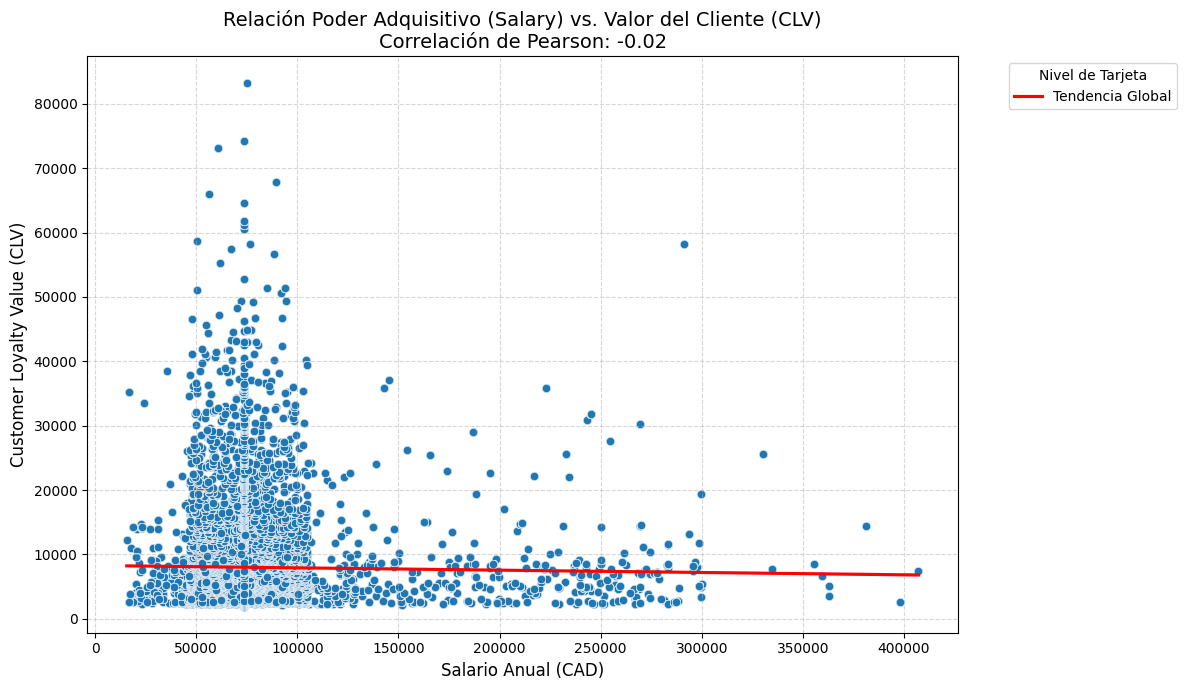

In [102]:
# lo represento en grafica para poder observar ese grado de correlacion tan bajo


corr_salary_clv = round(df_final_copia['salary'].corr(df_final_copia['c_l_v']), 2)


plt.figure(figsize=(12, 7))


sns.scatterplot(
    data=df_final_copia, 
    x='salary', 
    y='c_l_v', 

    palette='viridis', 
    alpha=0.6
)


sns.regplot(
    data=df_final_copia, 
    x='salary', 
    y='c_l_v', 
    scatter=False, 
    color='red', 
    label='Tendencia Global'
)

plt.title(f'Relación Poder Adquisitivo (Salary) vs. Valor del Cliente (CLV)\nCorrelación de Pearson: {corr_salary_clv}', fontsize=14)
plt.xlabel('Salario Anual (CAD)', fontsize=12)
plt.ylabel('Customer Loyalty Value (CLV)', fontsize=12)
plt.legend(title='Nivel de Tarjeta', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [103]:
# observamos que las personas con menos salario son las que mas aporta a la empresa durane toda la relaccion con ella.
# observando que la grafica es de grado positivo ya que el lado de la izquierda alarga mucho la grafica
# detectamos la presiencia de  Outliers , tanto en el salario a partir de los 300000 $ como en clv a partir de 50000 $


In [104]:
df_final_copia[['c_l_v','salary']].mean()

c_l_v      7990.864857
salary    77922.058198
dtype: float64

CATEGORICAS

In [105]:
#provincia mayoritaria que viven los clientes, ordenadas de la provincia donde mas se vive a donde menos

provincias = [['Ontario', 'Alberta', 'British Columbia', 'Quebec', 'Yukon', 
                'New Brunswick', 'Manitoba', 'Nova Scotia', 'Saskatchewan', 
                'Newfoundland', 'Prince Edward Island']]

resultados = []


for col in provincias[0]:
    porcentaje = round(((df_final_copia['province'] == col).sum() / df_final_copia.shape[0]) * 100, 2)
    resultados.append((col, porcentaje))


resultados_ordenados = sorted(resultados, key=lambda x: x[1], reverse=True)


for prov, porc in resultados_ordenados:
    print(f"{prov}: {porc}%")

# no hay ninguna provincia mayoritaria 


Ontario: 32.26%
British Columbia: 26.36%
Quebec: 19.71%
Alberta: 5.79%
Manitoba: 3.94%
New Brunswick: 3.8%
Nova Scotia: 3.1%
Saskatchewan: 2.44%
Newfoundland: 1.55%
Yukon: 0.66%
Prince Edward Island: 0.39%


In [106]:
# reparto por genero de nuestros clientes
# no es relevante destacar el genero ya que son parejos

print(round(((df_final_copia['gender']=='Male').sum()/df_final_copia.shape[0])*100,2), '% de los clientes son hombres') #sacamos el % en hombres
print (round(((df_final_copia['gender']=='Female').sum()/df_final_copia.shape[0])*100,2), '%  de las clientas son mujeres' )#sacamos el % en mujeres

49.78 % de los clientes son hombres
50.22 %  de las clientas son mujeres


In [107]:
# Se puede observar el % de educacion nuestros clientes
categorias_educacion= [['Bachelor', 'College', 'Master', 'High School or Below', 'Doctor']]

resultados = []


for col in categorias_educacion[0]:
    porcentaje = round(((df_final_copia['education'] == col).sum() / df_final_copia.shape[0]) * 100, 2)
    resultados.append((col, porcentaje))


resultados_ordenados = sorted(resultados, key=lambda x: x[1], reverse=True)

for prov, porc in resultados_ordenados:
    print(f"{prov}: {porc}%")


# observamos que son mas los son licenciaturas y estudios superiores , siendo un gran grupo estas dos categorias




Bachelor: 62.55%
College: 25.33%
High School or Below: 4.68%
Doctor: 4.39%
Master: 3.04%


In [108]:
# observamos el % buscando valores atipicos en esta columna pero  en principio , todo es normal
casados=round(((df_final_copia['marital_status'] == 'Married').sum() / df_final_copia.shape[0]) * 100, 2)
divorciados=round(((df_final_copia['marital_status'] == 'Divorced').sum() / df_final_copia.shape[0]) * 100, 2)
solteros=round(((df_final_copia['marital_status'] == 'Single').sum() / df_final_copia.shape[0]) * 100, 2)

print(f'Casados: {casados}%\nSolteros: {solteros}% \nDivorciados: {divorciados}%')

# mas del 50% son casados , o sea la mayoria

Casados: 58.16%
Solteros: 26.79% 
Divorciados: 15.05%


In [109]:
# la tarjeta que mas se vende 

Star=round(((df_final_copia['loyalty_card'] == 'Star').sum() / df_final_copia.shape[0]) * 100, 2)
Aurora=round(((df_final_copia['loyalty_card'] == 'Aurora').sum() / df_final_copia.shape[0]) * 100, 2)
Nova=round(((df_final_copia['loyalty_card'] == 'Nova').sum() / df_final_copia.shape[0]) * 100, 2)

print(f'Star: {Star}%%\nNova: {Nova}%\nAurora: {Aurora}' )

Star: 45.51%%
Nova: 33.9%
Aurora: 20.59


In [110]:
#tipo de inscripcion en el programa fidelizacion
from src.sacar_porciento import calcular_frecuencia

lista=('Standard', '2018 Promotion')
calcular_frecuencia(df_final_copia, lista, 'enrollment_type')

Standard: 94.22%
2018 Promotion: 5.78%


{'Standard': np.float64(94.22), '2018 Promotion': np.float64(5.78)}

##

## CONCLUSIONES 

##  Perfil del Cliente Mayoritario (Insight Final)

Tras el análisis de los datos integrados, hemos definido el perfil predominante de nuestro usuario:

###  Perfil Sociodemográfico

* **Estado Civil:** Mayoritariamente **Casados**.
* **Nivel Educativo:** Nivel superior (**Grado Universitario / Diplomatura**).
* **Poder Adquisitivo:** Salario medio anual en torno a los **78.000 $**.

###  Comportamiento de Vuelo

* **Frecuencia:** Realizan una media de **5 vuelos mensuales**, pero detectamos un área de mejora: **solo 1 de ellos es con nuestra compañía**.
* **Alcance:** Recorren una distancia media de **6.293 millas**.

###  Fidelización y Recompensa
* **Suscripción:** El **94%** opta por la **Inscripción Estándar**.
* **Nivel de Tarjeta:** La opción favorita es la **Tarjeta Star (45.51%)**.
* **Puntos:** Acumulan una media de **124.26 puntos** mensuales.
* **Retorno Económico:** El beneficio máximo percibido por el cliente es de **71 $**.

---



